# Лабораторна робота 1 — Дослідження даних з NumPy, Pandas та scikit-learn

**Набір даних:** `kc_house_data.csv`  
**Дозволені бібліотеки:** NumPy, Pandas, Matplotlib, scikit-learn (усі модулі)

## Налаштування — встановлення залежностей та імпорт

Запустіть комірку нижче один раз, щоб переконатись, що всі необхідні пакети встановлені.

In [1]:
# Встановлення залежностей (можна запускати повторно)
import sys
!{sys.executable} -m pip install numpy pandas matplotlib scikit-learn --quiet



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)


---
## Завдання 1 — Розминка з NumPy

**а)** Створіть масив NumPy з 10 000 значень, що підпорядковані нормальному розподілу N(0, 1). Обчисліть середнє, стандартне відхилення, мінімум і максимум за допомогою функцій NumPy — **без Python-циклів**.

**б)** Підрахуйте, скільки значень виходять за межі ±2 стандартних відхилення, використовуючи логічну індексацію. Яка це відсоткова частка? Порівняйте з теоретичним значенням ≈4,55 %.

In [9]:
data = np.random.normal(0, 1, 10000)
print(f"Середнє значення: {np.mean(data)}")
print(f"Стандартне відхилення: {np.std(data)}")
print(f"Мінімальне значення: {np.min(data)}")
print(f"Максимальне значення: {np.max(data)}")

Середнє значення: 0.0038432631909503636
Стандартне відхилення: 0.9908394931612651
Мінімальне значення: -3.773539168697238
Максимальне значення: 3.8813310399852696


In [10]:
std_v = np.std(data)
outliers = data[np.abs(data) > 2 * std_v]
print(f"Кількість значень поза межами ±2σ: {len(outliers)}")
print(f"Відсоткова частка викидів: {(len(outliers) / len(data)) * 100}%")

Кількість значень поза межами ±2σ: 451
Відсоткова частка викидів: 4.51%


**Ваша відповідь (б):Кількість значень поза межами ±2σ: 451
Відсоткова частка викидів: 4.51%


---
## Завдання 2 — Завантаження та огляд набору даних

Завантажте `kc_house_data.csv` у Pandas DataFrame та дайте відповідь на питання нижче, написавши код:

1. Скільки рядків і стовпців у наборі даних? Кількість рядків: 21613
Кількість стовпців: 21
2. Які мінімум, максимум, середнє та медіана цін на будинки?
Мінімальна ціна: 75000.0
Максимальна ціна: 7700000.0
Середня ціна: 540088.1417665294
Медіана цін: 450000.0
3. Скільки унікальних поштових індексів є у наборі даних? Який поштовий індекс має найбільше оголошень?
Кількість унікальних поштових індексів: 70
Поштовий індекс з найбільшою кількістю оголошень: 98103

In [5]:
# Завантаження набору даних
sales = pd.read_csv('kc_house_data.csv')
sales.head()


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [11]:
print(f"Кількість рядків: {sales.shape[0]}")
print(f"Кількість стовпців: {sales.shape[1]}")

Кількість рядків: 21613
Кількість стовпців: 21


In [12]:
print(f"Мінімальна ціна: {sales['price'].min()}")
print(f"Максимальна ціна: {sales['price'].max()}")
print(f"Середня ціна: {sales['price'].mean()}")
print(f"Медіана цін: {sales['price'].median()}")

Мінімальна ціна: 75000.0
Максимальна ціна: 7700000.0
Середня ціна: 540088.1417665294
Медіана цін: 450000.0


In [13]:
print(f"Кількість унікальних поштових індексів: {sales['zipcode'].nunique()}")
print(f"Поштовий індекс з найбільшою кількістю оголошень: {sales['zipcode'].value_counts().idxmax()}")

Кількість унікальних поштових індексів: 70
Поштовий індекс з найбільшою кількістю оголошень: 98103


---
## Завдання 3 — Візуалізація даних

Створіть **два графіки поруч**:

- **Лівий:** гістограма `price` (50 інтервалів, логарифмічна шкала по осі X).
- **Правий:** діаграма розсіювання `sqft_living` vs `price`, де кольором точок позначено `bedrooms`. Додайте підписи осей і colorbar.

Одним реченням для кожного графіка опишіть, що ви спостерігаєте.

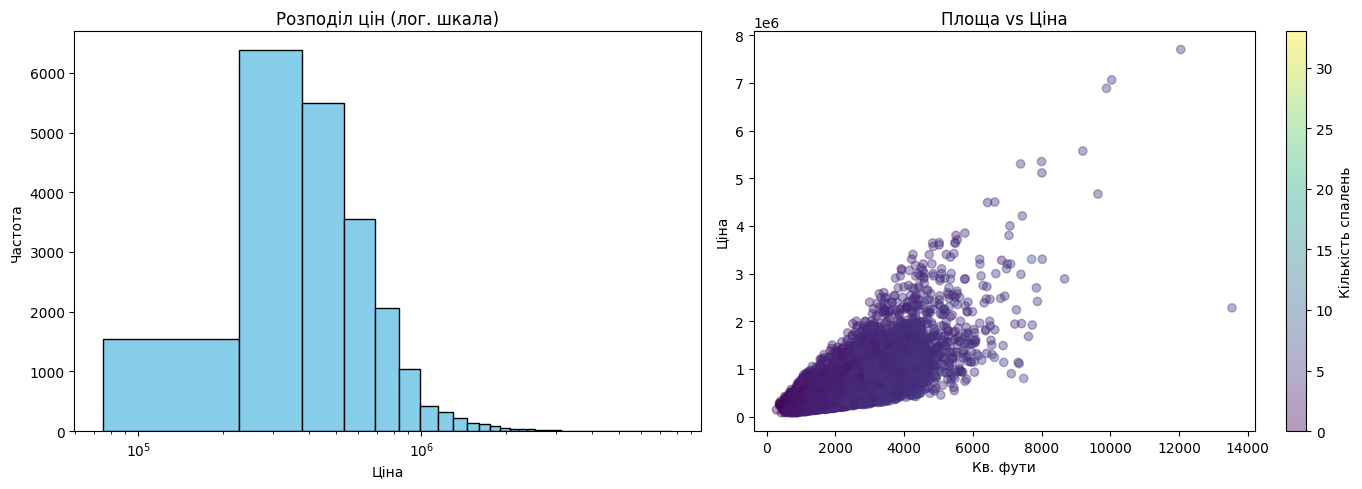

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(sales['price'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_xscale('log')
axes[0].set_title('Розподіл цін (лог. шкала)')
axes[0].set_xlabel('Ціна')
axes[0].set_ylabel('Частота')

sc = axes[1].scatter(sales['sqft_living'], sales['price'], c=sales['bedrooms'], cmap='viridis', alpha=0.4)
axes[1].set_title('Площа vs Ціна')
axes[1].set_xlabel('Кв. фути')
axes[1].set_ylabel('Ціна')
fig.colorbar(sc, ax=axes[1], label='Кількість спалень')

plt.tight_layout()
plt.show()

**Спостереження (лівий графік):** Гістограма демонструє, що ціни на нерухомість мають логнормальний розподіл, де основна маса об'єктів зосереджена в ціновому діапазоні від $300,000$ до $700,000$ доларів.

**Спостереження (правий графік):** Діаграма розсіювання вказує на чітку пряму залежність між житловою площею та ціною, де будинки з більшою квадратурою зазвичай мають більшу кількість спалень і вищу вартість.

---
## Завдання 4 — Навчання та оцінка регресійної моделі

Розбийте дані 80/20 (`random_state=42`). Навчіть `LinearRegression` з scikit-learn для передбачення `price` за єдиною ознакою `sqft_living`.

1. Вкажіть вільний член (intercept) та коефіцієнт для `sqft_living`.
2. Обчисліть MSE і RMSE на тестовій вибірці.
3. Яка передбачувана ціна будинку площею 2 500 кв. футів?

In [15]:
# Поділ на навчальну та тестову вибірки
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)


In [17]:
train_data, test_data = train_test_split(sales, test_size=0.2, random_state=42)

X_train = train_data[['sqft_living']]
y_train = train_data['price']
X_test = test_data[['sqft_living']]
y_test = test_data['price']

model1 = LinearRegression().fit(X_train, y_train)

print(f"Вільний член (Intercept): {model1.intercept_}")
print(f"Коефіцієнт для sqft_living: {model1.coef_[0]}")

y_pred = model1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Середньоквадратична помилка (MSE): {mse}")
print(f"Корінь з MSE (RMSE): {rmse}")
X_new = pd.DataFrame([[2500]], columns=['sqft_living'])
pred_2500 = model1.predict(X_new)[0]
print(f"Передбачувана ціна для будинку 2500 кв. футів: {pred_2500}")

Вільний член (Intercept): -41999.1860399358
Коефіцієнт для sqft_living: 279.5547793152631
Середньоквадратична помилка (MSE): 76484977061.77612
Корінь з MSE (RMSE): 276559.1746114674
Передбачувана ціна для будинку 2500 кв. футів: 656887.7622482219


---
## Завдання 5 — Порівняння двох моделей

Навчіть другу `LinearRegression` з ознаками: `sqft_living`, `bedrooms`, `bathrooms`, `yr_built`. Порівняйте RMSE на тестовій вибірці між Моделлю 1 та Моделлю 2. Яке значення нижче? Коротко поясніть чому.

In [18]:
feat2 = ['sqft_living', 'bedrooms', 'bathrooms', 'yr_built']
model2 = LinearRegression().fit(train_data[feat2], y_train)

y2_pred = model2.predict(test_data[feat2])
rmse2 = np.sqrt(mean_squared_error(y_test, y2_pred))

print(f"RMSE Моделі 1 (тільки площа): {rmse}")
print(f"RMSE Моделі 2 (чотири ознаки): {rmse2}")

RMSE Моделі 1 (тільки площа): 276559.1746114674
RMSE Моделі 2 (чотири ознаки): 262985.9758719034


**Відповідь:** Значення RMSE нижче у Моделі 2 ($262,985$ проти $276,559$). Це пояснюється тим, що ціна будинку залежить не лише від його площі, а й від інших факторів: кількість спалень та ванних кімнат вказує на зручність планування, а рік побудови — на стан комунікацій та сучасність об'єкта. Додавання цих додаткових ознак дозволило моделі краще "зрозуміти" дані та точніше прогнозувати вартість, що призвело до зменшення середньої похибки.

---
## ✨ Бонус — Аналіз залишків

Для вашої кращої моделі обчисліть вектор залишків (predicted − actual). Побудуйте гістограму. Чи виглядають залишки нормально розподіленими та центрованими навколо нуля? Що означав би систематичний ненульовий середній залишок?

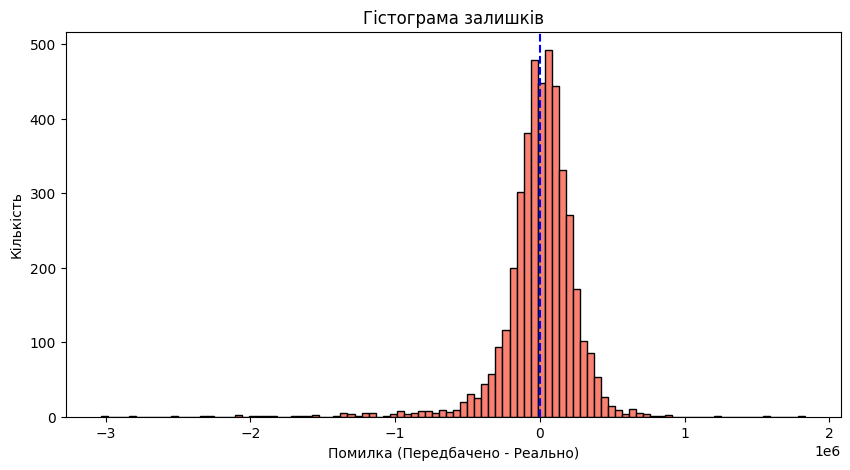

Середнє значення залишків: -1611.506214134028


In [19]:
res = model2.predict(test_data[feat2]) - y_test
plt.hist(res, bins=100, color='salmon', edgecolor='black')
plt.axvline(0, color='blue', linestyle='--')
plt.title('Гістограма залишків')
plt.xlabel('Помилка (Передбачено - Реально)')
plt.ylabel('Кількість')
plt.show()

print(f"Середнє значення залишків: {np.mean(res)}")

**Спостереження:** Залишки мають форму, близьку до дзвоноподібної, та чітко центровані навколо нуля, що свідчить про те, що модель в середньому робить правильні прогнози без систематичних відхилень. Хоча розподіл нагадує нормальний, на графіку помітні «довгі хвости» (особливо в бік великих значень), що вказує на наявність об'єктів-викидів, де модель помиляється сильніше. Якби середній залишок був систематично ненульовим, це означало б наявність зміщення (bias) у моделі — ситуацію, коли вона постійно або занижує, або завищує реальну вартість будинків через невраховані закономірності в даних.